In [16]:
import matplotlib.pyplot as plt
import numpy as np

from skimage import filters
from skimage import exposure

# Dyskretyzacja

Zad 1, 2, 3

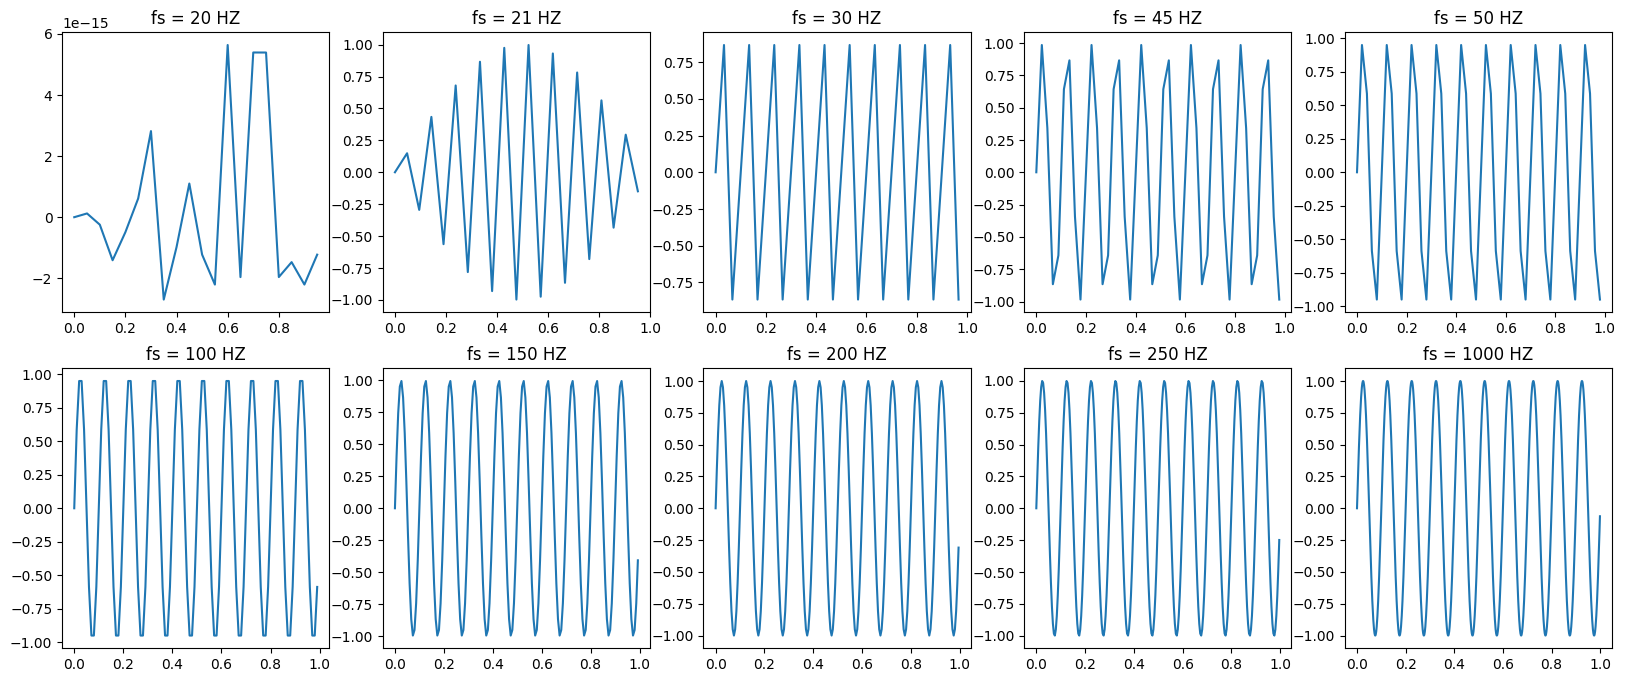

In [17]:
def sin(f, fs):
    t = np.arange(0, 1, 1/fs)
    s = np.sin(2*np.pi*f*t)
    return t, s

tab = [20, 21, 30, 45, 50, 100, 150, 200, 250, 1000]
plt.figure(figsize=(20, 8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    s = sin(10, tab[i])
    plt.plot(s[0], s[1])
    plt.title(f"fs = {tab[i]} HZ")
plt.show()

Zad 4

Tak, twierdzenie o próbkowaniu Nyquista-Shannona

Zad 5

Aliasing

Zad 6

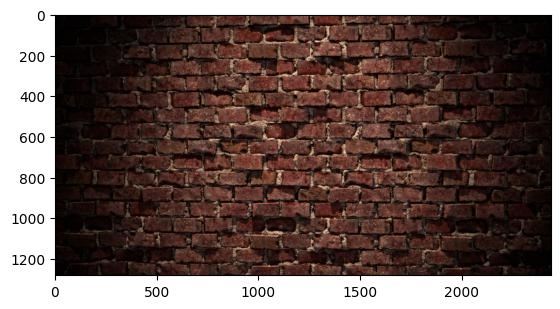

In [18]:
img = plt.imread("brick-wall.png")
plt.imshow(img)
plt.show()

Zad 7

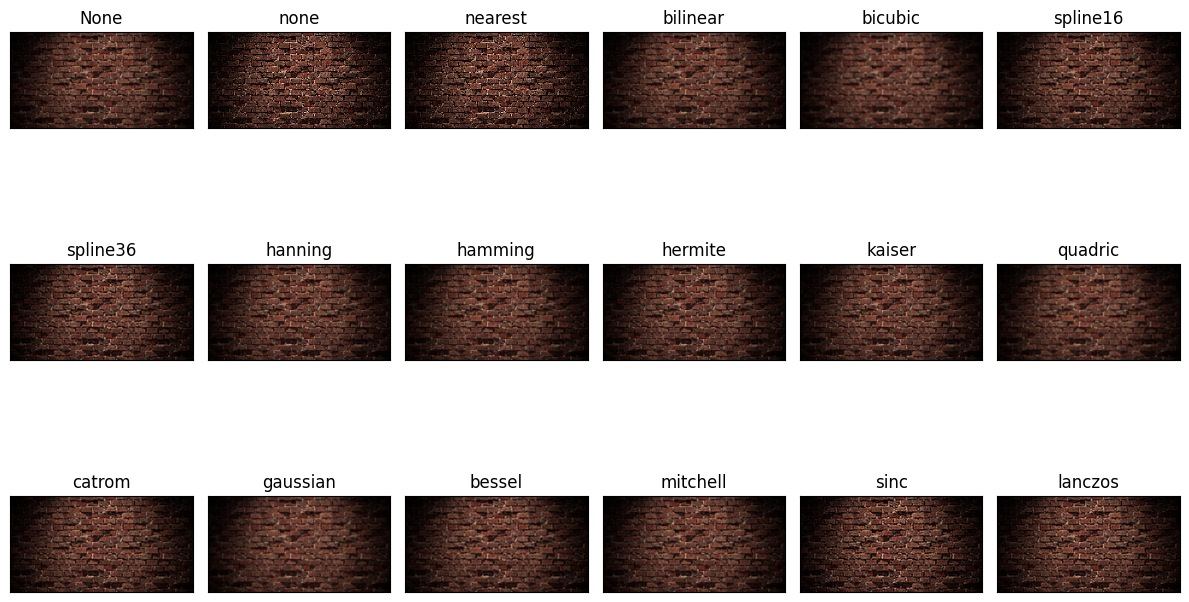

In [19]:
methods = [None, 'none', 'nearest', 'bilinear', 'bicubic', 'spline16',
           'spline36', 'hanning', 'hamming', 'hermite', 'kaiser', 'quadric',
           'catrom', 'gaussian', 'bessel', 'mitchell', 'sinc', 'lanczos']

img = plt.imread("brick-wall.png")

fig, axs = plt.subplots(nrows=3, ncols=6, figsize=(12, 8),
                        subplot_kw={'xticks': [], 'yticks': []})

for ax, interp_method in zip(axs.flat, methods):
    ax.imshow(img, interpolation=interp_method)
    ax.set_title(str(interp_method))

plt.tight_layout()
plt.show()

# Kwantyzacja

Zad 1

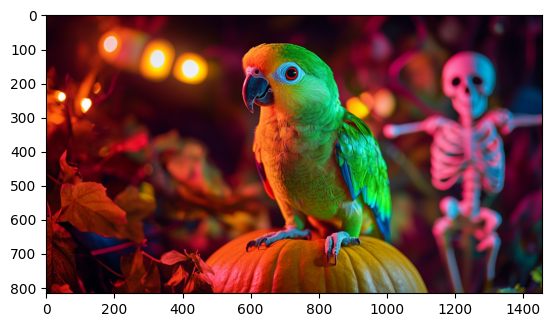

In [20]:
img = plt.imread("parrot2.png")
plt.imshow(img)
plt.show()

Zad 2

In [21]:
print(img.ndim)

3


Zad 3

In [22]:
print(img.shape)
# wartość 3.

(816, 1456, 3)


Zad 4

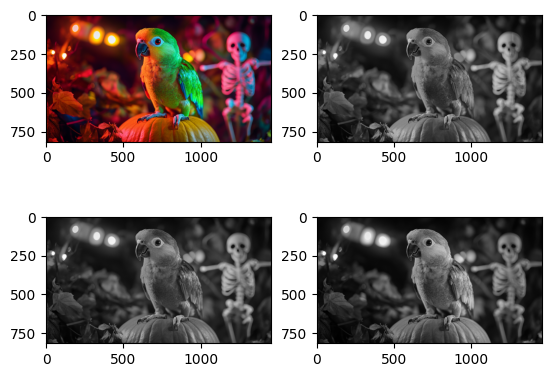

In [23]:
img1 = (np.max(img, axis=2) + np.min(img, axis=2)) / 2
img2 = np.mean(img, axis=2)
img3 = 0.21*img[:,:,0] + 0.72*img[:,:,1] + 0.07*img[:,:,2]

plt.subplot(2, 2, 1)
plt.imshow(img)

plt.subplot(2, 2, 2)
plt.imshow(img1, cmap="gray")

plt.subplot(2, 2, 3)
plt.imshow(img2, cmap="gray")

plt.subplot(2, 2, 4)
plt.imshow(img3, cmap="gray")

plt.show()

Zad 5

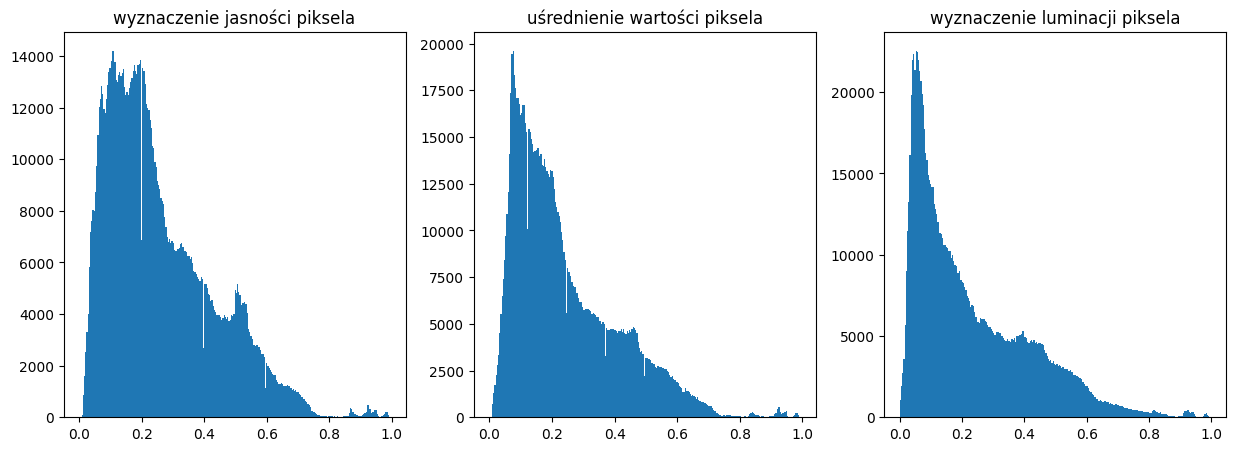

In [24]:
x1, b1 = np.histogram(img1, bins=256)
x2, b2 = np.histogram(img2, bins=256)
x3, b3 = np.histogram(img3, bins=256)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(b1[:-1], b1, weights=x1)
plt.title("wyznaczenie jasności piksela")

plt.subplot(1, 3, 2)
plt.hist(b2[:-1], b2, weights=x2)
plt.title("uśrednienie wartości piksela")

plt.subplot(1, 3, 3)
plt.hist(b3[:-1], b3, weights=x3)
plt.title("wyznaczenie luminacji piksela")

plt.show()

Zad 6

In [25]:
x1_reduced, b1_reduced = np.histogram(img1, bins=16)
print(b1_reduced)

[0.         0.06213235 0.1242647  0.18639705 0.2485294  0.31066176
 0.3727941  0.43492645 0.4970588  0.55919117 0.6213235  0.6834559
 0.7455882  0.80772054 0.8698529  0.93198526 0.9941176 ]


Zad 7

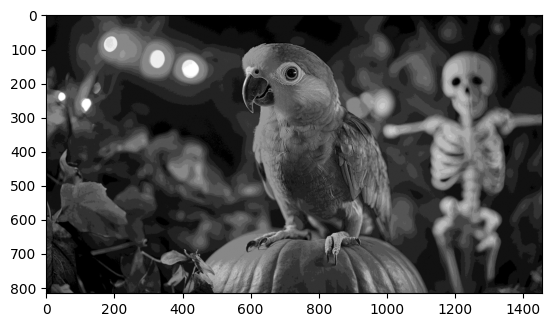

In [26]:
n_bins = 16

hist, edges = np.histogram(img1, bins=n_bins)

c = (edges[:-1] + edges[1:]) / 2

id = np.digitize(img1, edges) - 1
id = np.clip(id, 0, len(c) - 1)

img_reduced = c[id]

plt.imshow(img_reduced, cmap='gray')
plt.show()

Zad 8

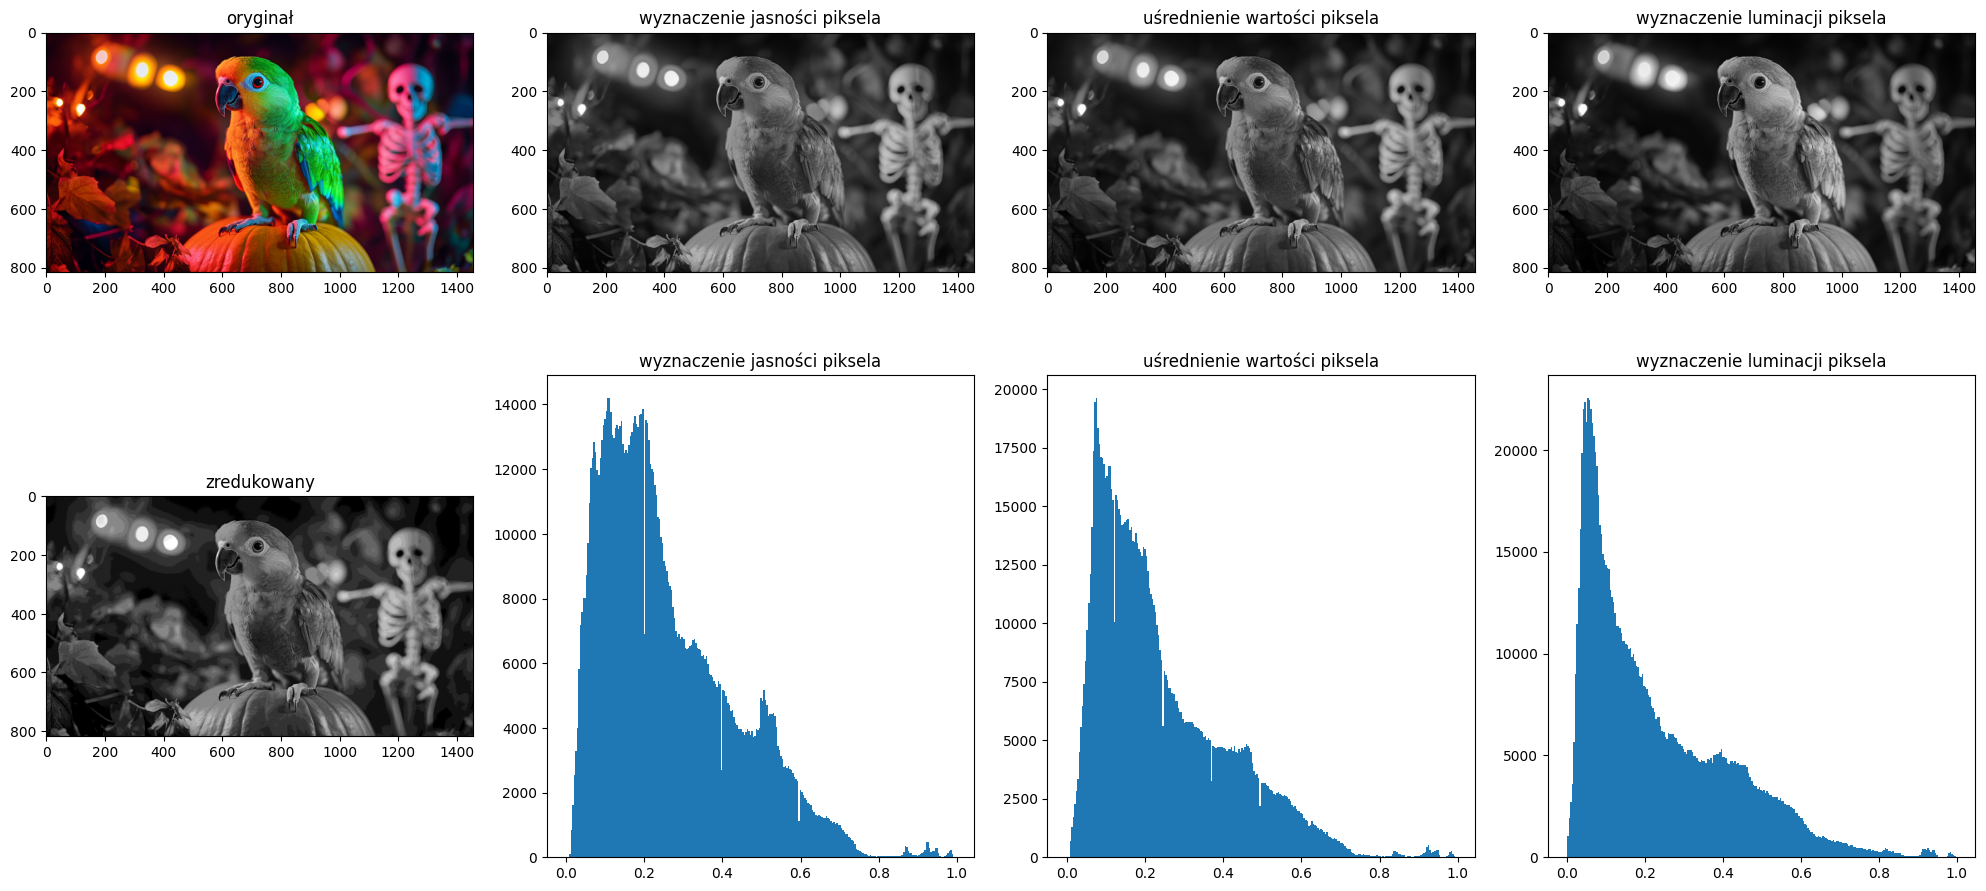

In [27]:
plt.figure(figsize=(20, 10))

plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title('oryginał')

plt.subplot(2, 4, 2)
plt.imshow(img1, cmap="gray")
plt.title('wyznaczenie jasności piksela')

plt.subplot(2, 4, 3)
plt.imshow(img2, cmap="gray")
plt.title('uśrednienie wartości piksela')

plt.subplot(2, 4, 4)
plt.imshow(img3, cmap="gray")
plt.title('wyznaczenie luminacji piksela')

plt.subplot(2, 4, 5)
plt.imshow(img_reduced, cmap="gray")
plt.title('zredukowany')

plt.subplot(2, 4, 6)
plt.hist(b1[:-1], b1, weights=x1)
plt.title('wyznaczenie jasności piksela')

plt.subplot(2, 4, 7)
plt.hist(b2[:-1], b2, weights=x2)
plt.title('uśrednienie wartości piksela')

plt.subplot(2, 4, 8)
plt.hist(b3[:-1], b3, weights=x3)
plt.title('wyznaczenie luminacji piksela')

plt.tight_layout()
plt.show()

# Binaryzacja

Zad 1,2

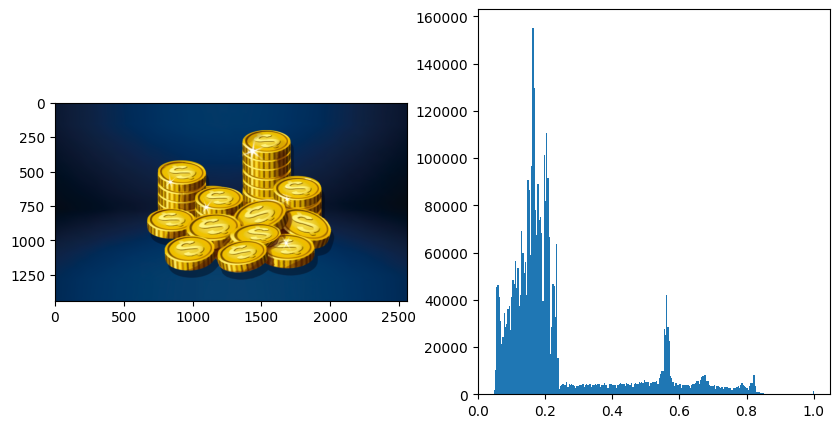

In [40]:
img = plt.imread('coins2.png')
img5 = np.mean(img, axis=2)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)

plt.subplot(1, 2, 2)
x5, b5 = np.histogram(img5, bins=256)
plt.hist(b5[:-1], b5, weights=x5)
plt.show()

Zad 3, 4, 5

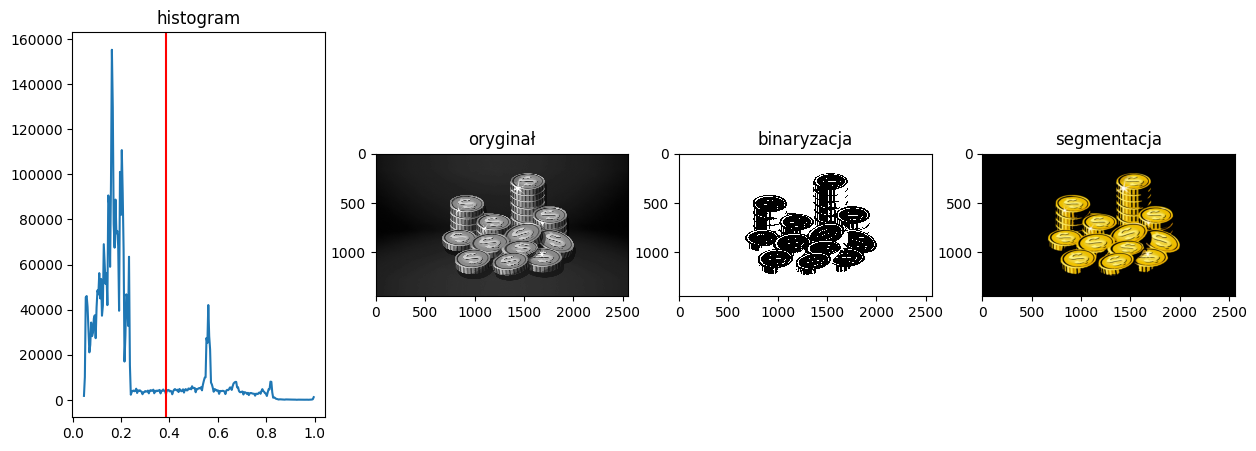

In [37]:
def prog(hist, od, do):
    return np.argmin(hist[od:do]) + od

val = prog(x5, 55, 141) / 255

plt.figure(figsize=(15,5))

plt.subplot(1, 4, 1)
plt.plot(b5[:-1], x5)
plt.axvline(val, color="r")
plt.title('histogram')

plt.subplot(1, 4, 2)
plt.imshow(img5, cmap="gray", interpolation='nearest')
plt.title('oryginał')

plt.subplot(1, 4, 3)
plt.imshow(img5 < val, cmap="gray", interpolation='nearest')
plt.title('binaryzacja')

img_c = img.copy()
img_c[img5 < val,:]=0

plt.subplot(1, 4, 4)
plt.imshow(img_c)
plt.title('segmentacja')

plt.show()